# Single-Cell RNA-seq: PBMC3k End-to-End Walkthrough
Standard scRNA-seq pipeline on 10x PBMC3k (2,700 PBMCs):
environment → AnnData exploration → QC → normalization → feature selection →
dimensionality reduction → clustering. Built with Scanpy + AnnData.
Run top to bottom (Kernel → Restart & Run All).

## 1. Environment & Setup

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

sc.settings.verbosity = 2
sc.logging.print_header()

Package,Version
scanpy,1.11.5
numpy,2.4.6
pandas,2.3.3
Component,Info
Python,"3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:29:05) [Clang 19.1.7 ]"
OS,macOS-26.5.1-arm64-arm-64bit
CPU,"10/10 logical CPU cores, arm"
GPU,No GPU found
Updated,2026-06-27 02:42
Dependency,Version


In [3]:
adata = sc.datasets.pbmc3k()

## 2. The AnnData object
PBMC3k loads as an **AnnData** object — Scanpy's core structure. It bundles the
expression matrix with aligned per-cell and per-gene metadata:
- `.X` — expression matrix (cells × genes), raw UMI counts
- `.obs` — per-cell metadata (one row per cell) 
- `.var` — per-gene metadata (one row per gene)
- `.obsm` — per-cell embeddings (PCA, UMAP), filled in later
- `.raw` — frozen all-genes snapshot, set later

In [4]:
print("Shape (cells, genes):", adata.shape)
print("Stored non-zeros:", adata.X.nnz,
    f"({adata.X.nnz / (adata.shape[0]*adata.shape[1]) * 100:.1f}% filled — the rest are zeros)")
print("\nCorner (first 5 cells x 5 genes):")
print(adata.X[:5, :5].toarray())

Shape (cells, genes): (2700, 32738)
Stored non-zeros: 2286884 (2.6% filled — the rest are zeros)

Corner (first 5 cells x 5 genes):
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [5]:
adata.obs.head()      # per-cell metadata (just barcodes for now)

""
index
AAACATACAACCAC-1
AAACATTGAGCTAC-1
AAACATTGATCAGC-1
AAACCGTGCTTCCG-1
AAACCGTGTATGCG-1


In [6]:
adata.var.head()      # per-gene metadata (gene symbols + Ensembl IDs)

,gene_ids
index,
MIR1302-10,ENSG00000243485
FAM138A,ENSG00000237613
OR4F5,ENSG00000186092
RP11-34P13.7,ENSG00000238009
RP11-34P13.8,ENSG00000239945


## 3. Quality Control

In [7]:
adata.var['mt']= adata.var_names.str.startswith('MT-')
print(adata.var['mt'].sum())
adata.var[adata.var['mt']].head() 

13


,gene_ids,mt
index,,
MT-ND1,ENSG00000198888,True
MT-ND2,ENSG00000198763,True
MT-CO1,ENSG00000198804,True
MT-CO2,ENSG00000198712,True
MT-ATP8,ENSG00000228253,True


In [8]:
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)
adata.obs.head()
# adata.obs[['n_genes_by_counts','total_counts','pct_counts_mt']].describe() # provides complete statistical information

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,total_counts_mt,log1p_total_counts_mt,pct_counts_mt
index,,,,,,,
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,73.0,4.304065,3.015283
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,186.0,5.231109,3.793596
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,28.0,3.367296,0.889171
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,46.0,3.850147,1.743085
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,12.0,2.564949,1.223242


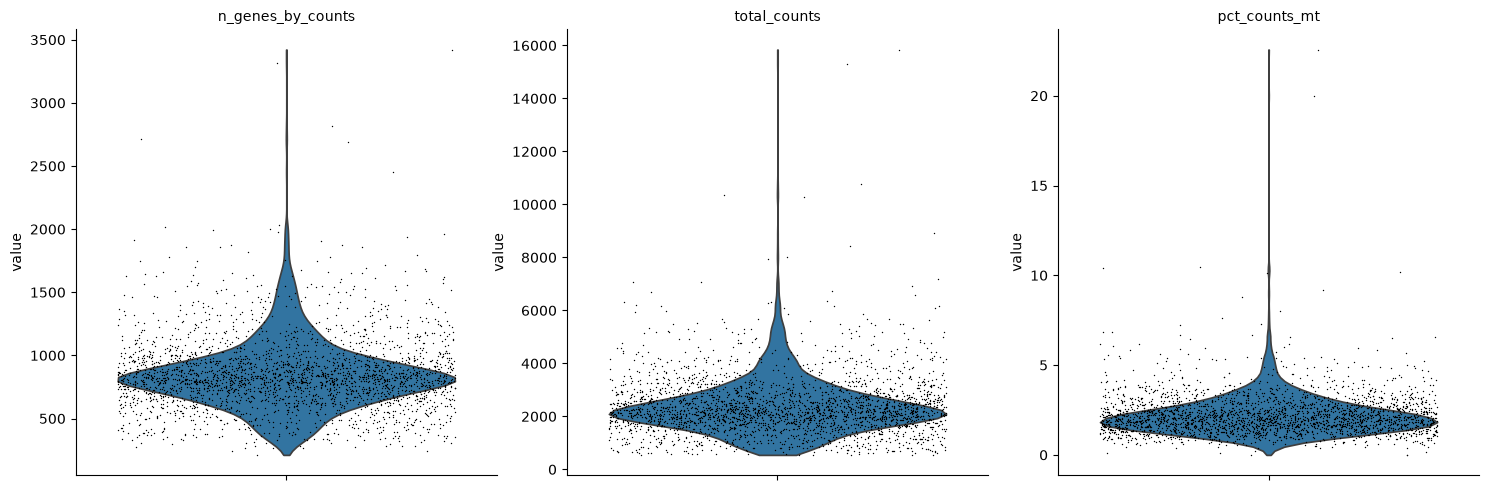

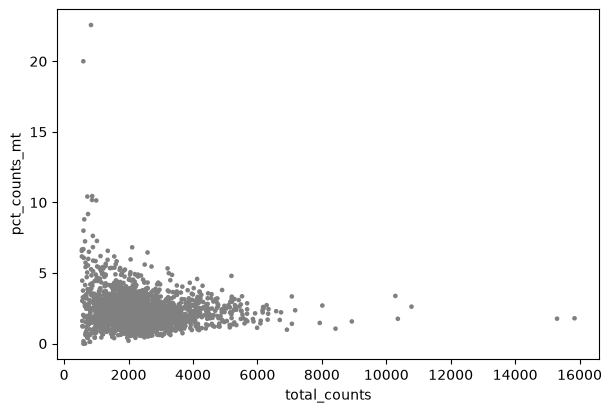

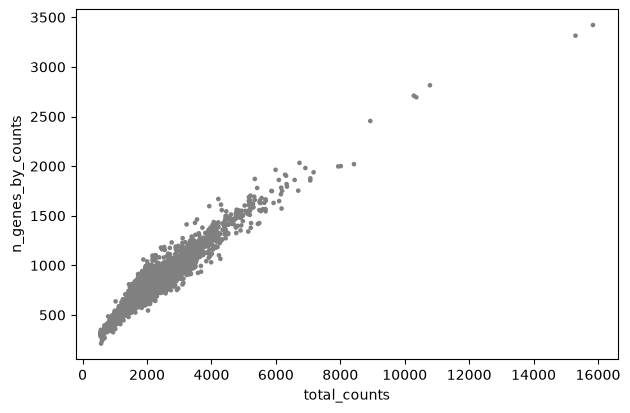

In [9]:
sc.pl.violin(adata, ['n_genes_by_counts','total_counts','pct_counts_mt'],
           jitter=0.4, multi_panel=True)
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

### Basic filtering

In [10]:
print(adata.shape)                # before
sc.pp.filter_cells(adata, min_genes=200)
print(adata.shape)                # fewer CELLS now
sc.pp.filter_genes(adata, min_cells=3)
print(adata.shape)      

(2700, 32738)
(2700, 32738)
filtered out 19024 genes that are detected in less than 3 cells
(2700, 13714)


In [11]:
print("cells to remove:", (adata.obs.pct_counts_mt >= 5).sum())
adata = adata[adata.obs.pct_counts_mt < 5].copy()
print(adata.shape)                # fewer cells again

cells to remove: 57
(2643, 13714)


## 4. Normalize + log
#### The normalization formula is (raw/total)* target sum  - Here the target sum is CP10k (Counts per 10000)
#### The reason log1p is used is because cell counts have many zeros and log0 is error/undefined. Hence (1+x) will atleast give log1=0 clean not undefined.

In [12]:
print(adata.X[:3, :8].toarray())
print("max value now:", adata.X.max())

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
max value now: 419.0


In [13]:
sc.pp.normalize_total(adata, target_sum=1e4)
print(adata.X.sum(axis=1)[:5]) 

normalizing counts per cell
    finished (0:00:00)
[[10000.   ]
 [10000.   ]
 [10000.   ]
 [ 9999.998]
 [10000.001]]


In [14]:
sc.pp.log1p(adata)
# look at the SAME corner AFTER (fractional, log-scaled, smaller range):
print(adata.X[:3, :8].toarray())
print("max value now:", adata.X.max())

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
max value now: 7.4695992


## 5. Highly Variable Genes

extracting highly variable genes
    finished (0:00:00)
2000


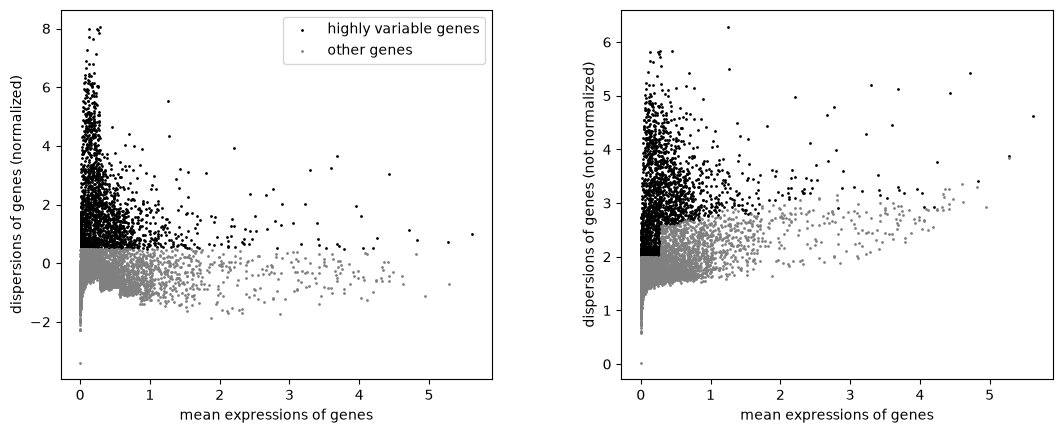

In [15]:
sc.pp.highly_variable_genes(adata, n_top_genes = 2000)
# confirm ~2000 flagged + see the new var columns:
print(adata.var['highly_variable'].sum())    # 2000
adata.var.head()                              # new cols: highly_variable, means, dispersions
sc.pl.highly_variable_genes(adata)            # the HVG plot


In [16]:
adata.raw = adata
print(adata.raw.shape)
print(adata.shape)
adata = adata[:, adata.var.highly_variable].copy()
print(adata.shape)                #now (cells, 2000)
print(adata.raw.shape)            #still all genes — raw preserved

(2643, 13714)
(2643, 13714)
(2643, 2000)
(2643, 13714)


## 6. Dimensionality Reduction & Clustering
Scale genes, reduce to 30 PCs, build the neighbor graph, then visualize (UMAP) and
cluster (Leiden). Clusters are colored by marker genes to identify cell types. 

computing PCA
    with n_comps=30


/Users/sneha/anaconda3/envs/scrna/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


    finished (0:00:00)
computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:00:03)
computing UMAP
    finished (0:00:02)
running Leiden clustering
    finished (0:00:00)


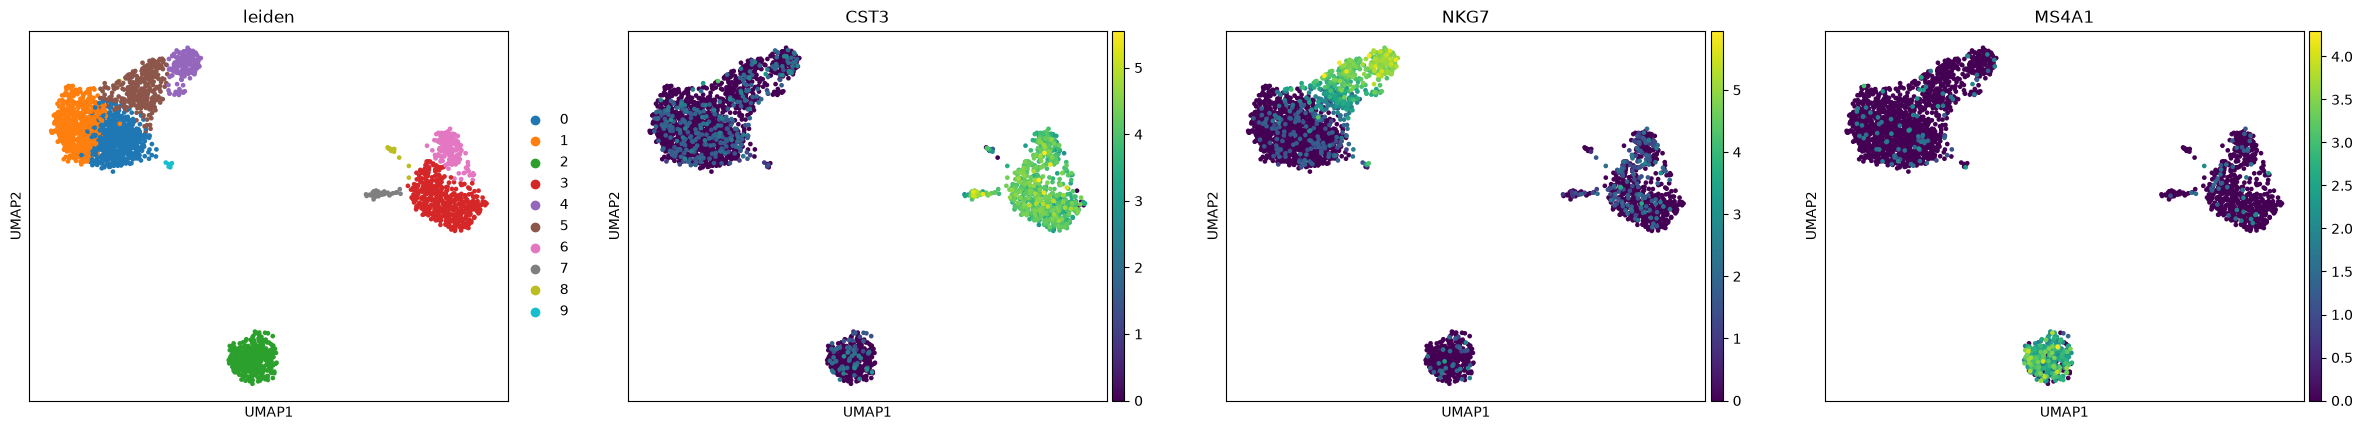

In [17]:
sc.pp.scale(adata, max_value = 10)
sc.tl.pca(adata, n_comps=30)
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1.0, flavor = 'igraph', n_iterations=2, directed = False)

sc.pl.umap(adata, color=['leiden', 'CST3', 'NKG7', 'MS4A1'])# markers: monocyte, NK, B

## 7. Summary
Starting from 2,700 raw PBMC profiles, the standard pipeline (QC → normalization →
HVG → PCA → clustering) produced distinct clusters matching expected PBMC populations,
identified via canonical markers: CST3 (monocytes), NKG7 (NK cells), MS4A1 (B cells).
This establishes the workflow applied to the breast-cancer DDR analysis next